In [ ]:
print("Hello, I am starting my internship!")

Hello, I am starting my internship!


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded!")
print(df.shape)

Dataset loaded!
(891, 12)


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Fill missing Age with the average age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Drop the Cabin column entirely (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

# Fill missing Embarked with the most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Confirm no more missing values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipython-input-497/766360548.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-497/766360548.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

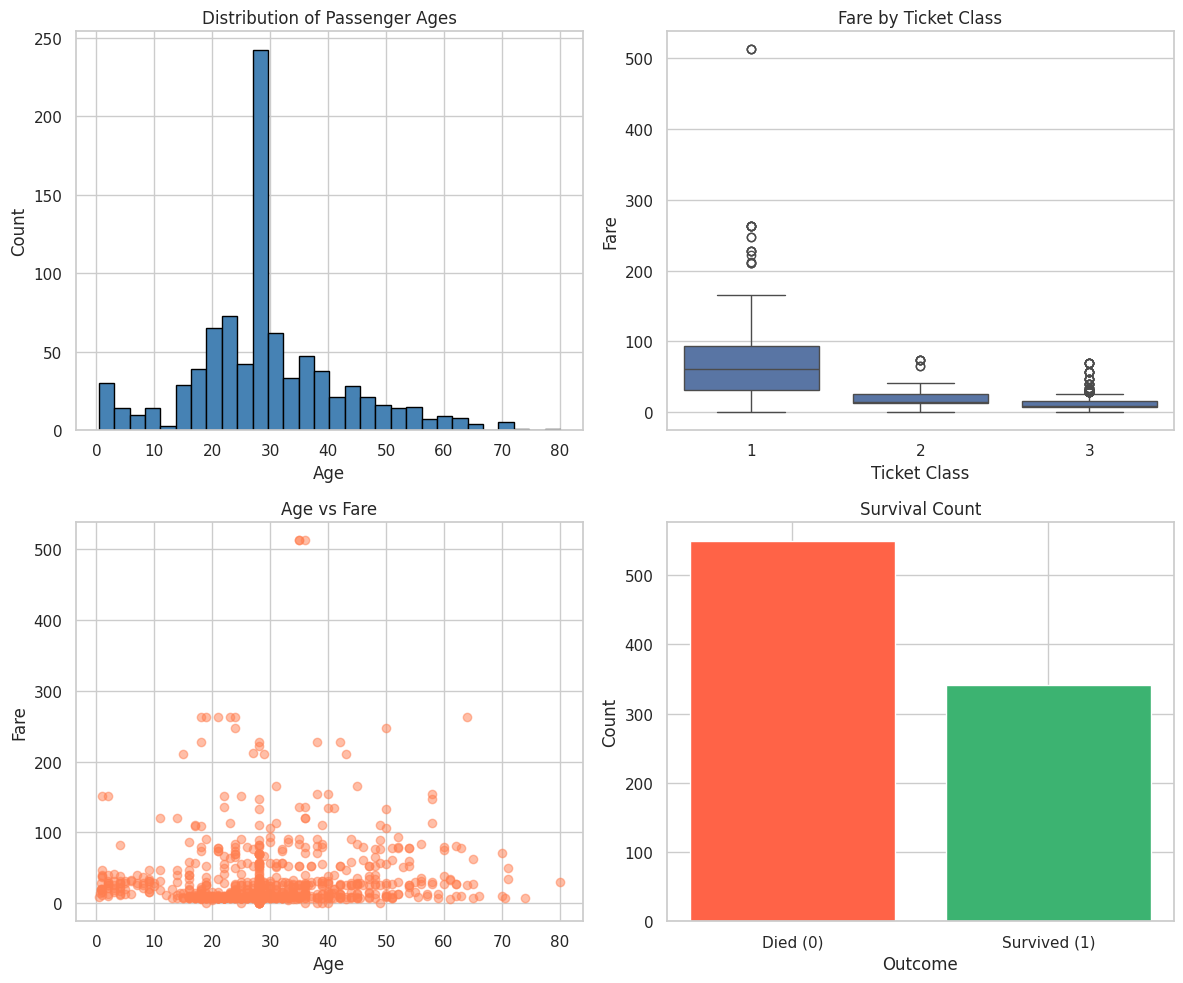

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make the plots look nice
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Histogram - Age distribution
axes[0,0].hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribution of Passenger Ages')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# 2. Boxplot - Fare by Pclass
sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[0,1])
axes[0,1].set_title('Fare by Ticket Class')
axes[0,1].set_xlabel('Ticket Class')
axes[0,1].set_ylabel('Fare')

# 3. Scatter - Age vs Fare
axes[1,0].scatter(df['Age'], df['Fare'], alpha=0.5, color='coral')
axes[1,0].set_title('Age vs Fare')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Fare')

# 4. Bar - Survival count
survival_counts = df['Survived'].value_counts()
axes[1,1].bar(['Died (0)', 'Survived (1)'], survival_counts.values, color=['tomato', 'mediumseagreen'])
axes[1,1].set_title('Survival Count')
axes[1,1].set_xlabel('Outcome')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Set up our X (input) and y (output)
X = df[['Age']]
y = df['Fare']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Report results
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 25.45
RMSE: 39.05


In [ ]:
# Convert Sex to numbers: male = 0, female = 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Convert Embarked to numbers: S = 0, C = 1, Q = 2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Choose which columns we'll use to predict survival
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features]
y = df['Survived']

print("Ready!")
print(f"Input shape: {X.shape}")
print(f"Survival counts:\n{y.value_counts()}")

Ready!
Input shape: (891, 7)
Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 712
Testing samples: 179


In [ ]:
# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# --- Cross Validation Scores ---
lr_cv = cross_val_score(lr_model, X, y, cv=5).mean()
rf_cv = cross_val_score(rf_model, X, y, cv=5).mean()

# --- Print all metrics ---
def print_metrics(name, y_test, y_pred, cv_score):
    print(f"\n{name}")
    print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"  F1 Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred):.4f}")
    print(f"  Cross-Val: {cv_score:.4f}")

print_metrics("Logistic Regression", y_test, lr_pred, lr_cv)
print_metrics("Random Forest", y_test, rf_pred, rf_cv)


Logistic Regression
  Accuracy:  0.7989
  Precision: 0.7714
  Recall:    0.7297
  F1 Score:  0.7500
  ROC-AUC:   0.7887
  Cross-Val: 0.7935

Random Forest
  Accuracy:  0.8268
  Precision: 0.8116
  Recall:    0.7568
  F1 Score:  0.7832
  ROC-AUC:   0.8165
  Cross-Val: 0.8115


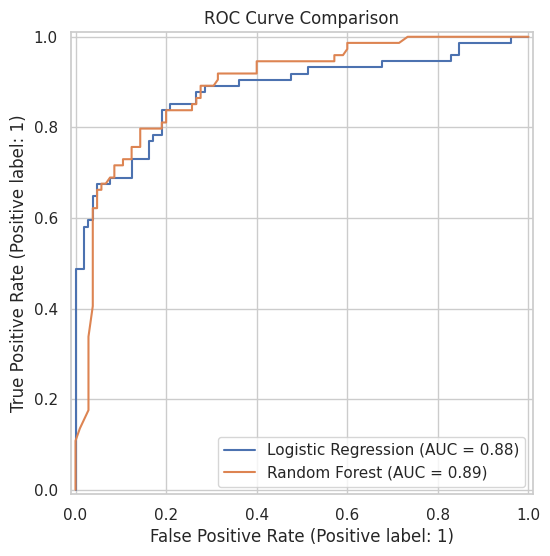

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(lr_model, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, name="Random Forest")

ax.set_title("ROC Curve Comparison")
plt.show()

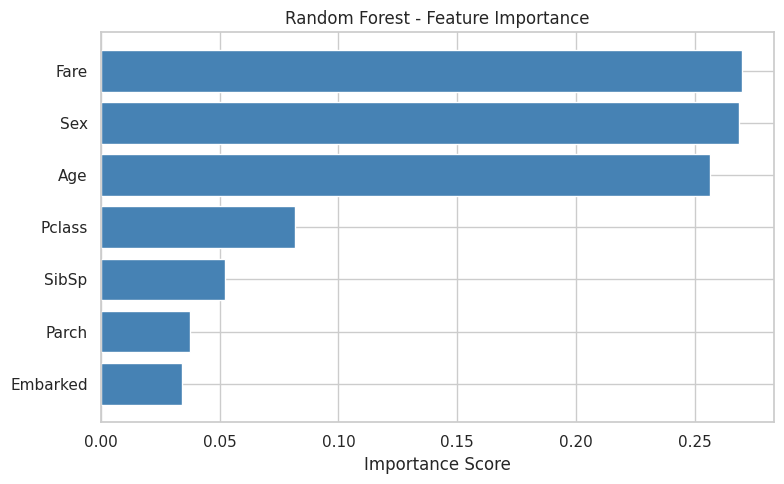

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from Random Forest
importances = rf_model.feature_importances_
feature_names = features

# Sort them
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Task 1 - Classification Model Report

## Dataset
- Titanic passenger dataset (891 rows, 12 columns)
- Goal: Predict whether a passenger survived (1) or died (0)

## Data Preprocessing
- Dropped Cabin column (687 missing values)
- Filled missing Age values with median age
- Filled missing Embarked values with most common value
- Converted Sex and Embarked from text to numbers

## Models Compared
1. Logistic Regression
2. Random Forest (100 trees)

## Results

| Metric | Logistic Regression | Random Forest |
|--------|-------------------|---------------|
| Accuracy | 79.89% | 82.68% |
| Precision | 77.14% | 81.16% |
| Recall | 72.97% | 75.68% |
| F1 Score | 0.75 | 0.78 |
| ROC-AUC | 0.79 | 0.82 |
| Cross-Val | 79.35% | 81.15% |

## Model Selection
Random Forest was selected as the better model as it outperformed
Logistic Regression on every single metric.

## Key Findings
- Fare, Sex, and Age were the most important features
- Female passengers had significantly higher survival rates
- Higher fare (and therefore higher class) correlated with survival
- The model achieved 82.68% accuracy on unseen test data